In [ ]:
pip install xarray netcdf4 rioxarray matplotlib pandas numpy

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

### Uploading the files and printing the file details and variable details

In [6]:
gldas_gw = xr.open_dataset(r"D:\IITB Mini_projects\GNR644\GLDAS_MonthlyGWS\PENINSULAR_INDIA_GLDAS_GWS_cm_Monthly_2003_2024.nc")
print(gldas_gw)

<xarray.Dataset> Size: 5MB
Dimensions:      (lon: 75, lat: 67, time: 263)
Coordinates:
  * lon          (lon) float32 300B 72.62 72.88 73.12 ... 90.62 90.88 91.12
  * lat          (lat) float32 268B 8.125 8.375 8.625 ... 24.12 24.38 24.62
  * time         (time) datetime64[ns] 2kB 2003-02-01 2003-03-01 ... 2024-12-01
Data variables:
    spatial_ref  int64 8B ...
    GWS_tavg     (time, lat, lon) float32 5MB ...


In [9]:
gldas_gw_var = gldas_gw['GWS_tavg']
print("GroundWater(GLDAS):", gldas_gw.data_vars)
print(gldas_gw_var)

GroundWater(GLDAS): Data variables:
    spatial_ref  int64 8B ...
    GWS_tavg     (time, lat, lon) float32 5MB ...
<xarray.DataArray 'GWS_tavg' (time: 263, lat: 67, lon: 75)> Size: 5MB
[1321575 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 300B 72.62 72.88 73.12 73.38 ... 90.62 90.88 91.12
  * lat      (lat) float32 268B 8.125 8.375 8.625 8.875 ... 24.12 24.38 24.62
  * time     (time) datetime64[ns] 2kB 2003-02-01 2003-03-01 ... 2024-12-01
Attributes:
    units:            cm
    conversion_note:  Converted from mm to cm (1 cm = 10 mm)
    grid_mapping:     spatial_ref


### Plotting the Time Series map using the mean of Peninsular Basin (GLDAS GW)

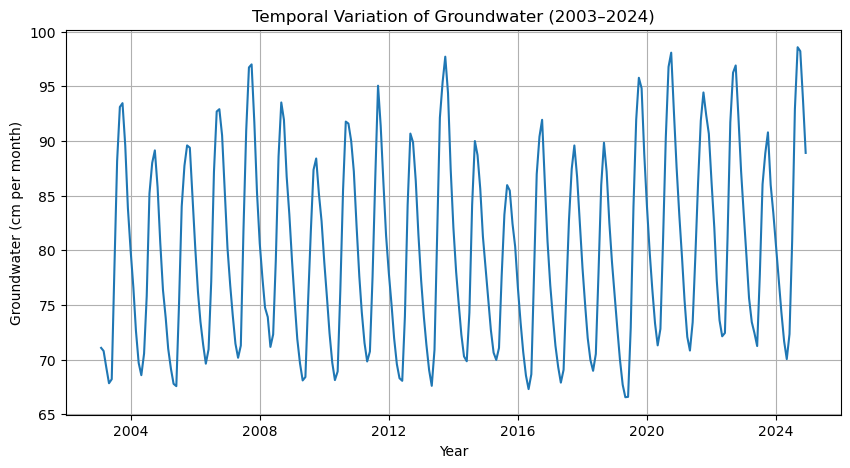

In [11]:
gldas_gw_ts = gldas_gw_var.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

gldas_gw_ts.plot(label='GLDAS (Groundwater)')

plt.title("Temporal Variation of Groundwater (2003–2024)")
plt.xlabel("Year")
plt.ylabel("Groundwater (cm per month)")
plt.grid(True)

plt.show()

### Grouping the mean by Month

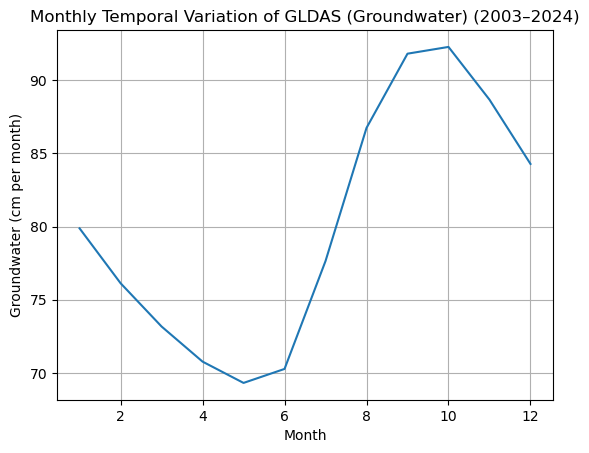

In [13]:
gldas_gw_season = gldas_gw_ts.groupby('time.month').mean()
gldas_gw_season.plot(label='GLDAS (Groundwater)')
plt.title("Monthly Temporal Variation of GLDAS (Groundwater) (2003–2024)")
plt.xlabel("Month")
plt.ylabel("Groundwater (cm per month)")
plt.grid(True)

### Trend Analysis

In [15]:
import numpy as np
from scipy.stats import linregress

time_gldas_gw = np.arange(len(gldas_gw_ts))

slope, intercept, r, p, std = linregress(time_gldas_gw, gldas_gw_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.013789798993456845
p-value: 0.048344194296359194


#### Since the slope is greater than 0, it is increasing

### Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [16]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for GLDAS (Groundwater) from 2003 to 2024')

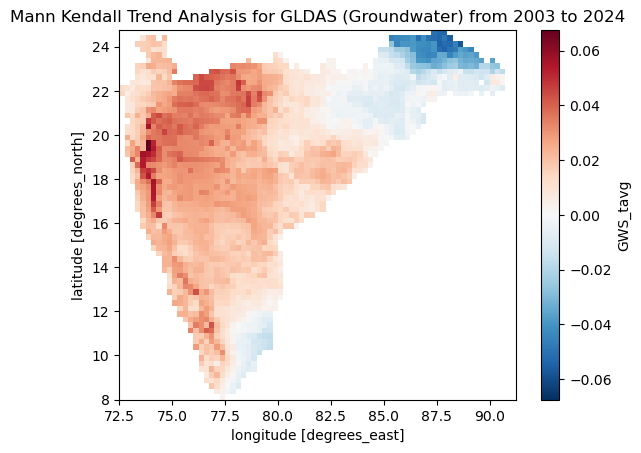

In [17]:
et_trend = xr.apply_ufunc(
    trend_calc,
    gldas_gw_var,
    input_core_dims=[['time']],
    vectorize=True
)

et_trend.plot()
plt.title("Mann Kendall Trend Analysis for GLDAS (Groundwater) from 2003 to 2024")

### Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for GLDAS (Groundwater)')

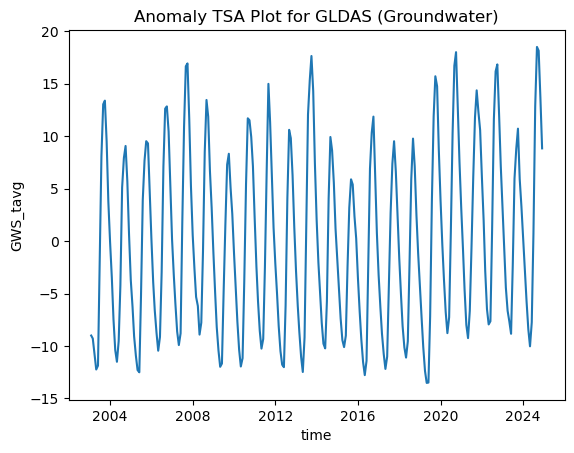

In [19]:
gldas_gw_mean = gldas_gw_ts.mean()
gldas_gw_anomaly = gldas_gw_ts - gldas_gw_mean

gldas_gw_anomaly.plot()
plt.title("Anomaly TSA Plot for GLDAS (Groundwater)") 